In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('datasets\\data_ecommerce_customer_churn.csv')
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [2]:
len(df.columns)

11

In [3]:
df.shape

(3941, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


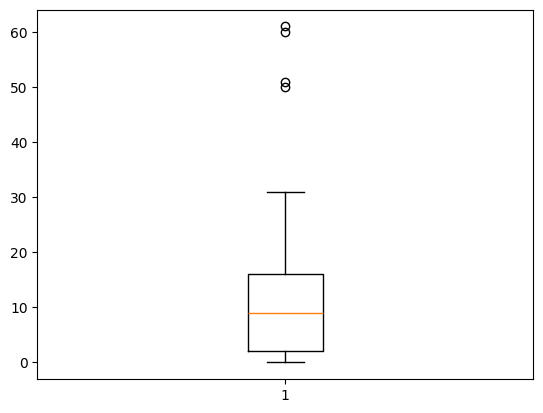

In [7]:
import matplotlib.pyplot as plt
plt.boxplot(df['Tenure'].dropna())
plt.show()

In [8]:
df.describe()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
count,3747.000000,3772.000000,3941.000000,3941.000000,3941.000000,3941.000000,3728.000000,3941.000000,3941.000000
mean,10.081398,15.650583,3.679269,3.088302,4.237757,0.282416,4.531652,176.707419,0.171023
std,8.498864,8.452301,1.013938,1.381832,2.626699,0.450232,3.667648,48.791784,0.376576
min,0.000000,5.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,9.000000,3.000000,2.000000,2.000000,0.000000,2.000000,145.700000,0.000000
50%,9.000000,14.000000,4.000000,3.000000,3.000000,0.000000,3.000000,163.340000,0.000000
75%,16.000000,21.000000,4.000000,4.000000,6.000000,1.000000,7.000000,195.250000,0.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,1.000000,46.000000,324.990000,1.000000


In [9]:
df['Tenure'] = df['Tenure'].fillna(df['Tenure'].median())
df['WarehouseToHome'] = df['WarehouseToHome'].fillna(df['WarehouseToHome'].median())
df['DaySinceLastOrder'] = df['DaySinceLastOrder'].fillna(df['DaySinceLastOrder'].mean())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3941 non-null   float64
 1   WarehouseToHome           3941 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3941 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


In [10]:
df['PreferedOrderCat'].value_counts()

PreferedOrderCat
Laptop & Accessory    1458
Mobile Phone           887
Fashion                585
Mobile                 559
Grocery                273
Others                 179
Name: count, dtype: int64

In [11]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married     2055
Single      1310
Divorced     576
Name: count, dtype: int64

In [12]:
df = pd.get_dummies(df, columns=['PreferedOrderCat', 'MaritalStatus'], drop_first=True)
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,15.0,29.0,4,3,2,0,7.000000,143.32,0,False,True,False,False,False,False,True
1,7.0,25.0,4,1,2,0,7.000000,129.29,0,False,False,True,False,False,True,False
2,27.0,13.0,3,1,5,0,7.000000,168.54,0,False,True,False,False,False,True,False
3,20.0,25.0,4,3,7,0,4.531652,230.27,0,False,False,False,False,False,False,False
4,30.0,15.0,4,4,8,0,8.000000,322.17,0,False,False,False,False,True,False,True


In [17]:
X = df.drop('Churn', axis=1)
y = df['Churn']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y,random_state=42)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train.shape, X_test.shape

((3152, 15), (789, 15))

In [19]:
y_train.value_counts(normalize=True)

Churn
0    0.828997
1    0.171003
Name: proportion, dtype: float64

In [20]:
y_test.value_counts(normalize=True)

Churn
0    0.828897
1    0.171103
Name: proportion, dtype: float64

In [21]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=None, oob_score=True)
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)
y_prob = rf.predict_proba(X_test_scaled)[:,1]

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
print("Random Forest Tree")
print("="*45)
print(f"   Training Accuracy : {rf.score(X_train, y_train):.4f}")
print(f"   Testing Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"   Precision.        : {precision_score(y_test, y_pred):.4f}")
print(f"   Recall.           : {recall_score(y_test, y_pred):.4f}")
print(f"   F1 Score.         : {f1_score(y_test, y_pred):.4f}")
print(f"   Auc Roc.          : {roc_auc_score(y_test, y_prob):.4f}")
print(f"   OOB Score         : {rf.oob_score_:.4f}")

Random Forest Tree
   Training Accuracy : 0.8398
   Testing Accuracy  : 0.9379
   Precision.        : 0.9057
   Recall.           : 0.7111
   F1 Score.         : 0.7967
   Auc Roc.          : 0.9600
   OOB Score         : 0.9369


C:\Users\rahit\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


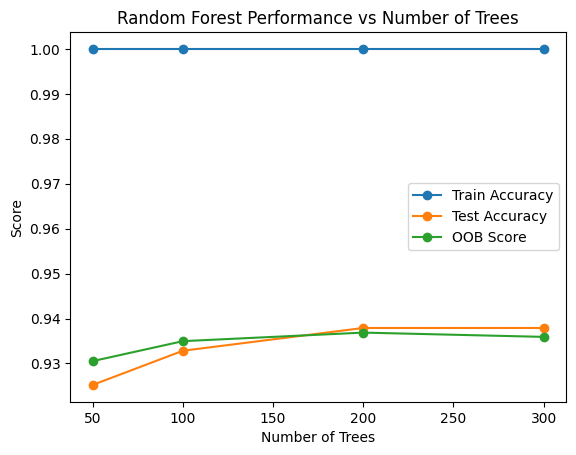

In [22]:
trees = [50,100,200,300]
train_accs, test_accs, oob_scores = [],[],[]
for n in trees:
    rf = RandomForestClassifier(random_state=42, n_estimators=n, max_depth=None, oob_score=True)
    rf.fit(X_train_scaled, y_train)
    train_accs.append(rf.score(X_train_scaled, y_train))
    test_accs.append(accuracy_score(y_test, rf.predict(X_test_scaled)))
    oob_scores.append(rf.oob_score_)
plt.plot(trees, train_accs, label='Train Accuracy', marker='o')
plt.plot(trees, test_accs, label='Test Accuracy', marker='o')
plt.plot(trees, oob_scores, label='OOB Score', marker='o')
plt.xlabel('Number of Trees')
plt.ylabel('Score')
plt.title('Random Forest Performance vs Number of Trees')
plt.legend()
plt.show() 

In [23]:
print(f"{'n_trees':>8} {'Train Acc':>10} {'Test Acc':>10} {'OOB Score':>10}")
print("-" * 42)
for n, tr, te, oob in zip(trees, train_accs, test_accs, oob_scores):
    print(f"{n:>8} {tr:>10.4f} {te:>10.4f} {oob:>10.4f}")

 n_trees  Train Acc   Test Acc  OOB Score
------------------------------------------
      50     1.0000     0.9252     0.9305
     100     1.0000     0.9328     0.9350
     200     1.0000     0.9379     0.9369
     300     1.0000     0.9379     0.9359


In [24]:
coff = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
coff.sort_values(by='Importance', ascending=False, inplace=True)
coff

,Feature,Importance
0,Tenure,0.252527
7,CashbackAmount,0.167754
1,WarehouseToHome,0.107591
6,DaySinceLastOrder,0.088786
4,NumberOfAddress,0.088658
5,Complain,0.067880
3,SatisfactionScore,0.065465
2,NumberOfDeviceRegistered,0.053413
14,MaritalStatus_Single,0.029447
13,MaritalStatus_Married,0.020042


In [25]:
from sklearn.metrics import confusion_matrix, classification_report
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[644  10]
 [ 39  96]]


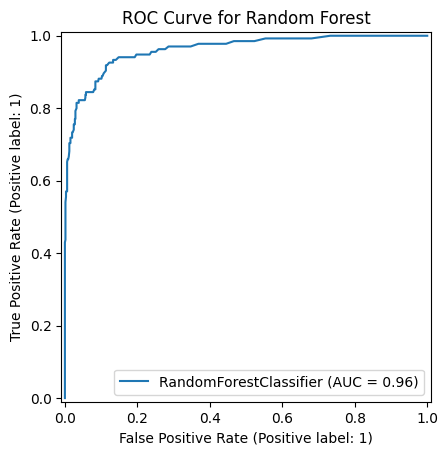

In [26]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(rf, X_test_scaled, y_test)
plt.title("ROC Curve for Random Forest")    
plt.show()

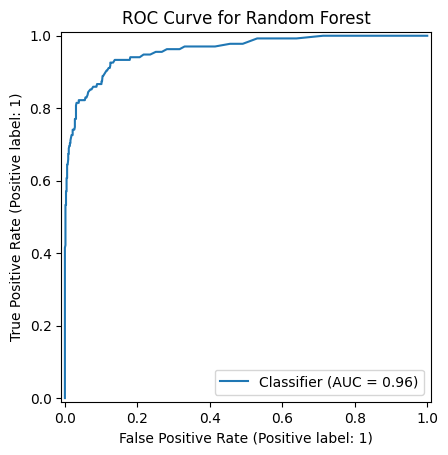

In [27]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve for Random Forest")    
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,RocCurveDisplay

def build_churn_model(csv_path):
    """Build and evaluate a Random Forest churn prediction model."""
    # Load and preprocess data
    df = pd.read_csv(csv_path)
    
    # Separate features and target, handle missing values
    X = df.drop('Churn', axis=1)
    y = df['Churn']
    
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            X[col].fillna(X[col].median() if X[col].dtype in ['float64', 'int64'] else X[col].mode()[0], inplace=True)
    
    # Perform stratified train-test split and train Random Forest
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    trees = [50,100,200,300]
    train_accs, test_accs, oob_scores = [],[],[]
    for t in trees:    
        rf = RandomForestClassifier(n_estimators=t, max_depth=None, random_state=42)
        rf.fit(X_train, y_train)
        train_accs.append(rf.score(X_train, y_train))
        test_accs.append(accuracy_score(y_test, rf.predict(X_test)))
        oob_scores.append(rf.oob_score_)
    
    # Evaluate and return results
    results = {
        'train_acc': train_accs,
        'test_acc': test_accs,
        'oob_score': oob_scores,
        'feature_importance': pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)
    }
    RocCurveDisplay.from_estimator(rf, X_test, y_test)
    plt.title("ROC Curve for Random Forest")
    plt.show()
    return results

# Uncomment and provide your CSV path to run the model
if __name__ == "__main__":
    result = build_churn_model('your_churn_data.csv')
